<a href="https://colab.research.google.com/github/Swaraj-sj2000/Machine-leaning-projects/blob/main/Trafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from collections import defaultdict, Counter
def get_vocab(corpus):
    """Convert corpus to character-level vocabulary with word frequencies."""
    vocab = defaultdict(int)
    for word in corpus.lower().split():
        # Add spaces between chars, mark end of word with </w>
        vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab
print(get_vocab("low low low lower lower lowest newest"))

defaultdict(<class 'int'>, {'l o w </w>': 3, 'l o w e r </w>': 2, 'l o w e s t </w>': 1, 'n e w e s t </w>': 1})


In [2]:
def get_pair_counts(vocab):
    """Count frequency of every adjacent symbol pair across all words."""
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        print(symbols)
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs
print(get_pair_counts(get_vocab("low low low lower lower lowest newest")))

['l', 'o', 'w', '</w>']
['l', 'o', 'w', 'e', 'r', '</w>']
['l', 'o', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
defaultdict(<class 'int'>, {('l', 'o'): 6, ('o', 'w'): 6, ('w', '</w>'): 3, ('w', 'e'): 4, ('e', 'r'): 2, ('r', '</w>'): 2, ('e', 's'): 2, ('s', 't'): 2, ('t', '</w>'): 2, ('n', 'e'): 1, ('e', 'w'): 1})


In [3]:
def merge_pair(pair, vocab):
    """Merge the most frequent pair everywhere in vocab."""
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

In [4]:
def run_bpe(corpus, num_merges):
    vocab = get_vocab(corpus)
    merges = []

    print("=== Initial vocab ===")
    for word, freq in vocab.items():
        print(f"  '{word}' : {freq}")

    for i in range(num_merges):
        pairs = get_pair_counts(vocab)
        if not pairs:
            break

        # Find the most frequent pair
        best_pair = max(pairs, key=pairs.get)
        merges.append(best_pair)

        print(f"\n--- Merge {i+1}: {best_pair} (freq={pairs[best_pair]}) ---")
        vocab = merge_pair(best_pair, vocab)

        print("Vocab now:")
        for word, freq in vocab.items():
            print(f"  '{word}' : {freq}")

    return vocab, merges


In [5]:
corpus = "low low low lower lower lowest newest"
final_vocab, merge_rules = run_bpe(corpus, num_merges=8)

print("\n=== Final tokens in vocabulary ===")
all_tokens = set()
for word in final_vocab:
    all_tokens.update(word.split())
print(sorted(all_tokens))

print(f"\nTotal merge rules learned: {len(merge_rules)}")
print("Merge rules (in order):")
for i, rule in enumerate(merge_rules, 1):
    print(f"  {i}. {rule[0]} + {rule[1]} → {''.join(rule)}")

=== Initial vocab ===
  'l o w </w>' : 3
  'l o w e r </w>' : 2
  'l o w e s t </w>' : 1
  'n e w e s t </w>' : 1
['l', 'o', 'w', '</w>']
['l', 'o', 'w', 'e', 'r', '</w>']
['l', 'o', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 1: ('l', 'o') (freq=6) ---
Vocab now:
  'lo w </w>' : 3
  'lo w e r </w>' : 2
  'lo w e s t </w>' : 1
  'n e w e s t </w>' : 1
['lo', 'w', '</w>']
['lo', 'w', 'e', 'r', '</w>']
['lo', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 2: ('lo', 'w') (freq=6) ---
Vocab now:
  'low </w>' : 3
  'low e r </w>' : 2
  'low e s t </w>' : 1
  'n e w e s t </w>' : 1
['low', '</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']

--- Merge 3: ('low', '</w>') (freq=3) ---
Vocab now:
  'low</w>' : 3
  'low e r </w>' : 2
  'low e s t </w>' : 1
  'n e w e s t </w>' : 1
['low</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '

In [6]:
print(merge_rules)

[('l', 'o'), ('lo', 'w'), ('low', '</w>'), ('low', 'e'), ('lowe', 'r'), ('lower', '</w>'), ('s', 't'), ('st', '</w>')]


In [7]:
def tokenise_word(word, merge_rules):
    """Apply learned BPE merge rules to a new word."""
    # Start as characters
    tokens = list(word) + ['</w>']
    print(tokens)
    for merge in merge_rules:
        i = 0
        new_tokens = []
        while i < len(tokens):
            # If current + next == the merge pair, merge them
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == merge:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
        if len(tokens) == 1:
            break
        print(tokens)

    return tokens

# Test on words the model has seen
print("low    →", tokenise_word("low", merge_rules))
print()
print("lower  →", tokenise_word("lower", merge_rules))
print()
print("lowest →", tokenise_word("lowest", merge_rules))
print()
print("newest →", tokenise_word("newest", merge_rules))
print()

# Test on a word the model has NEVER seen
print("lowers →", tokenise_word("lowers", merge_rules))
print()
print("lowly  →", tokenise_word("lowly", merge_rules))

['l', 'o', 'w', '</w>']
['lo', 'w', '</w>']
['low', '</w>']
low    → ['low</w>']

['l', 'o', 'w', 'e', 'r', '</w>']
['lo', 'w', 'e', 'r', '</w>']
['low', 'e', 'r', '</w>']
['low', 'e', 'r', '</w>']
['lowe', 'r', '</w>']
['lower', '</w>']
lower  → ['lower</w>']

['l', 'o', 'w', 'e', 's', 't', '</w>']
['lo', 'w', 'e', 's', 't', '</w>']
['low', 'e', 's', 't', '</w>']
['low', 'e', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 's', 't', '</w>']
['lowe', 'st', '</w>']
['lowe', 'st</w>']
lowest → ['lowe', 'st</w>']

['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 's', 't', '</w>']
['n', 'e', 'w', 'e', 'st', '</w>']
['n', 'e', 'w', 'e', 'st</w>']
newest → ['n', 'e', 'w', 'e', 'st</w>']

['l', 'o', 'w', 'e', 'r', 's', '</w>']
['lo', 'w', 'e', 'r', 's', '</w

In [8]:
import numpy as np
def positional_encoding(max_seq_len,d_model,base=10000):
  mat=np.zeros(shape=(max_seq_len,d_model))
  for i in range(max_seq_len):
    for j in range(d_model):
      if j%2:
        mat[i][j]=np.cos(i/(base**(2*j/d_model)))
      else:
        mat[i][j]=np.sin(i/(base**(2*j/d_model)))
  return mat

print(positional_encoding(4,5))



[[0.00000000e+00 1.00000000e+00 0.00000000e+00 1.00000000e+00
  0.00000000e+00]
 [8.41470985e-01 9.99684538e-01 6.30957303e-04 1.00000000e+00
  3.98107171e-07]
 [9.09297427e-01 9.98738351e-01 1.26191435e-03 9.99999999e-01
  7.96214341e-07]
 [1.41120008e-01 9.97162035e-01 1.89287090e-03 9.99999999e-01
  1.19432151e-06]]


[ 9.09297427e-01 -1.60435961e-01  9.97479998e-01  2.68690292e-01
  9.02130715e-01  5.62049196e-01  7.46903535e-01  7.44942117e-01
  5.91127117e-01  8.53732816e-01  4.56693360e-01  9.16839573e-01
  3.48205276e-01  9.52946237e-01  2.63553681e-01  9.73447913e-01
  1.98669331e-01  9.85039568e-01  1.49417212e-01  9.91577918e-01
  1.12231311e-01  9.95261000e-01  8.42393503e-02  9.97334142e-01
  6.32033979e-02  9.98500586e-01  4.74096958e-02  9.99156726e-01
  3.55580908e-02  9.99525763e-01  2.66672669e-02  9.99733308e-01
  1.99986667e-02  9.99850025e-01  1.49973219e-02  9.99915662e-01
  1.12465894e-02  9.99952573e-01  8.43383008e-03  9.99973330e-01
  6.32451316e-03  9.99985002e-01  4.74272963e-03  9.99991566e-01
  3.55655132e-03  9.99995257e-01  2.66703970e-03  9.99997333e-01
  1.99999867e-03  9.99998500e-01  1.49978786e-03  9.99999157e-01
  1.12468241e-03  9.99999526e-01  8.43392907e-04  9.99999733e-01
  6.32455490e-04  9.99999850e-01  4.74274723e-04  9.99999916e-01
  3.55655875e-04  9.99999

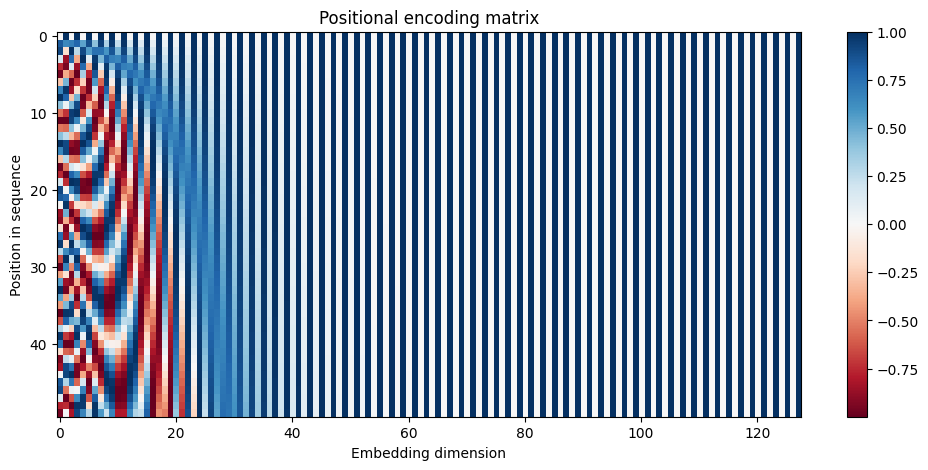

In [9]:
ps=positional_encoding(50,128)
print(ps[:][2])
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(12,5))
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Position in sequence')
ax.set_title('Positional encoding matrix')
fig.colorbar(ax.imshow(ps,cmap='RdBu',aspect='auto'),ax=ax)
plt.show()

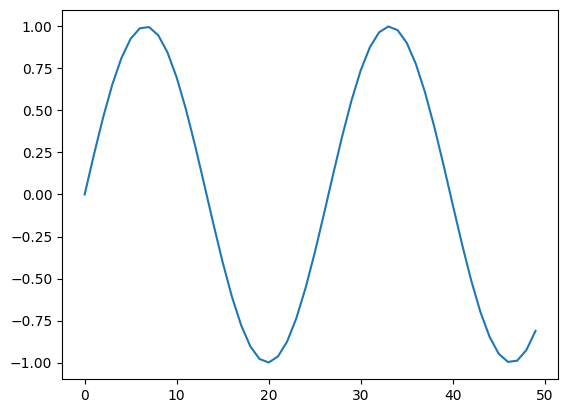

In [10]:
plt.plot(ps[:,10])
plt.show()

In [11]:
PE = positional_encoding(600, 128)

# Look at dimension 0 (fastest) for positions 3 and 503
print("Dim 0, pos 3:  ", round(PE[3, 0], 4))
print("Dim 0, pos 503 would need seq_len=600...")

# Fast dimension - does it repeat?
print("\nDim 0 across positions 0-10:")
print([round(PE[i, 0], 3) for i in range(10)])

print("\nDim 0 across positions 50-60:")
print([round(PE[i, 0], 3) for i in range(50, 60)])

Dim 0, pos 3:   0.1411
Dim 0, pos 503 would need seq_len=600...

Dim 0 across positions 0-10:
[np.float64(0.0), np.float64(0.841), np.float64(0.909), np.float64(0.141), np.float64(-0.757), np.float64(-0.959), np.float64(-0.279), np.float64(0.657), np.float64(0.989), np.float64(0.412)]

Dim 0 across positions 50-60:
[np.float64(-0.262), np.float64(0.67), np.float64(0.987), np.float64(0.396), np.float64(-0.559), np.float64(-1.0), np.float64(-0.522), np.float64(0.436), np.float64(0.993), np.float64(0.637)]


In [12]:
vocab_size=1000
d_model=128
token_ids=np.array([42, 891, 304, 17, 562])
print(token_ids.shape)
vector_embedding=np.random.rand(vocab_size,d_model)

def prepare_input(token_ids,vocab_size,d_model,vector_embedding):
  return vector_embedding[token_ids]+positional_encoding(token_ids.shape[0],d_model)


input_seq=prepare_input(token_ids,vocab_size,d_model,vector_embedding)



(5,)


In [13]:
def self_attention(vec_emb,Wq,Wk,Wv):

  Q=np.matmul(vec_emb,Wq)
  K=np.matmul(vec_emb,Wk)
  dk=K.shape[1]
  V=np.matmul(vec_emb,Wv)
  score=np.matmul(Q,np.transpose(K))
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)
  output=np.matmul(weights,V)
  return output



In [14]:
n_heads=8
d_k=d_model//n_heads
vec_emb=input_seq
Wq=np.random.rand(vec_emb.shape[1],d_k)
Wk=np.random.rand(vec_emb.shape[1],d_k)
Wv=np.random.rand(vec_emb.shape[1],d_k)
output=self_attention(vec_emb,Wq,Wk,Wv)
print(output)
print(output.shape)

[[65.66021409 61.81744026 72.89651878 58.7789826  61.36513709 63.99459213
  71.53584029 67.25166961 59.0809318  64.81039841 67.08099872 64.79337431
  66.93091826 67.49782069 63.79221263 69.79285414]
 [65.74008273 61.72845298 73.0877162  58.75120571 61.49149649 63.7577492
  71.55692992 67.12315889 59.07127073 64.70783944 66.85456523 64.91209526
  66.94405306 67.62270723 64.01087202 69.62143103]
 [65.8147024  61.64531397 73.2663481  58.72525432 61.60955153 63.53647161
  71.57663353 67.00309392 59.0622446  64.61202065 66.64301298 65.02301386
  66.95632463 67.7393862  64.21516109 69.46127388]
 [65.94736467 61.4975056  73.58392809 58.67911675 61.8194352  63.14307416
  71.61166352 66.78963689 59.04619752 64.44166962 66.26690567 65.22021003
  66.9781416  67.94682345 64.57835558 69.17653913]
 [66.0988038  61.32877661 73.94645798 58.62644893 62.05902555 62.6939957
  71.65165161 66.5459674  59.02787915 64.24720729 65.83756457 65.44531711
  67.00304651 68.18362112 64.99295619 68.85150336]]
(5, 16

In [15]:
def calculate_WQ_WK_WV(d_model,d_k):
  Wq=np.random.rand(d_model,d_k)
  Wk=np.random.rand(d_model,d_k)
  Wv=np.random.rand(d_model,d_k)
  return Wq,Wk,Wv

def calculate_Wo(d_model):
  return np.random.randn(d_model,d_model)

def multihead_attention(vec_emb,n_head):
  d_model=vec_emb.shape[1]
  d_k=d_model//n_head
  output=[]
  for i in range(n_head):
    Wq,Wk,Wv=calculate_WQ_WK_WV(d_model,d_k)
    op=self_attention(vec_emb,Wq,Wk,Wv)
    output.append(op)

  return np.matmul(np.hstack(output),calculate_Wo(d_model))

op=multihead_attention(vec_emb,n_head=8)

print(op.shape)




(5, 128)


In [16]:
def residual_layer(x,sublayer_output):
  return x+sublayer_output

def layer_norm(x,alpha,beta,eps):
  return (alpha*(x-np.mean(x,axis=1,keepdims=True))/(np.std(x,axis=1,keepdims=True)+eps))+beta

def add_and_norm(x,sublayer_output,alpha,beta,eps):
  return layer_norm(residual_layer(x,sublayer_output),alpha,beta,eps)


In [17]:
output=add_and_norm(vec_emb,multihead_attention(vec_emb,n_head=8),alpha=1,beta=0,eps=1e-6)
print(output.shape)

(5, 128)


In [18]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,ReLU,Input,Flatten,Dropout
from tensorflow.keras import Model



In [19]:
def ffn(output,d_model):
  d_ff1=4*d_model
  W1=np.random.randn(d_ff1,output.shape[1])
  b1=np.random.randn(d_ff1,)
  W2=np.random.randn(d_model,d_ff1)
  b2=np.random.randn(d_model,)
  l1=np.maximum(np.matmul(output,W1.T)+b1,0)
  l2=l1@W2.T+b2
  return l2

op2=ffn(output,d_model)
print(op2)


[[  95.29692797 -338.39218477    5.59912675  -75.13673288  112.25972697
   216.95112787  305.76556699  159.35941932   48.37397396 -115.06442542
   275.52963641   85.55151624 -104.92302066 -180.71113401 -104.70602192
   214.12504933   31.98235381 -208.35892391  304.02117324 -196.55898786
    99.0142437  -149.68935667  111.35849453   65.79211736  245.98636456
   -34.0736826  -180.97795972 -163.79119264  -99.29626769  146.27780731
   411.55066741 -293.627423     18.08490512  -89.88662678    2.34270712
   184.74578703  -13.03116613 -198.41361876  257.84637901  213.87304178
   145.68128848 -215.39422552  337.8095608   322.76709842   -7.87945361
   -69.40808804  139.88591389   79.31727719  293.7659631   111.01163793
   165.404924   -215.23073097  132.64719212  297.8918345  -111.84690982
  -351.46225493  117.76995271   43.50067717   27.51246796 -162.39024369
  -264.84643687   50.34106047  194.26882705  -99.43734118  -83.65760586
    97.0440557   -25.45192477   -0.47789247    5.86935431   53.2

In [20]:
vocab_size=1000
d_model=128
token_ids=np.array([42, 891, 304, 17, 562])
print(token_ids.shape)

vector_embedding=np.random.rand(vocab_size,d_model)

def prepare_input(token_ids,vocab_size,d_model,vector_embedding):
  return vector_embedding[token_ids]+positional_encoding(token_ids.shape[0],d_model)

def self_attention(vec_emb,Wq,Wk,Wv):
  Q=np.matmul(vec_emb,Wq)
  K=np.matmul(vec_emb,Wk)
  dk=K.shape[1]
  V=np.matmul(vec_emb,Wv)
  score=np.matmul(Q,np.transpose(K))
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)
  output=np.matmul(weights,V)
  return output

def calculate_WQ_WK_WV(d_model,d_k):
  Wq=np.random.rand(d_model,d_k)
  Wk=np.random.rand(d_model,d_k)
  Wv=np.random.rand(d_model,d_k)
  return Wq,Wk,Wv

def calculate_Wo(d_model):
  return np.random.randn(d_model,d_model)

def multihead_attention(vec_emb,n_head):
  d_model=vec_emb.shape[1]
  d_k=d_model//n_head
  output=[]
  for i in range(n_head):
    Wq,Wk,Wv=calculate_WQ_WK_WV(d_model,d_k)
    op=self_attention(vec_emb,Wq,Wk,Wv)
    output.append(op)

  return np.matmul(np.hstack(output),calculate_Wo(d_model))



def residual_layer(x,sublayer_output):
  return x+sublayer_output

def layer_norm(x,alpha,beta,eps):
  return (alpha*(x-np.mean(x,axis=1,keepdims=True))/(np.std(x,axis=1,keepdims=True)+eps))+beta

def add_and_norm(x,sublayer_output,alpha,beta,eps):
  return layer_norm(residual_layer(x,sublayer_output),alpha,beta,eps)

def ffn(output,d_model):
  d_ff1=4*d_model
  W1=np.random.randn(d_ff1,output.shape[1])
  b1=np.random.randn(d_ff1,)
  W2=np.random.randn(d_model,d_ff1)
  b2=np.random.randn(d_model,)
  l1=np.maximum(np.matmul(output,W1.T)+b1,0)
  l2=l1@W2.T+b2
  return l2

def encoder(vector_embedding,token_ids,vocab_size,d_model,n_head=8):
  input_seq=prepare_input(token_ids,vocab_size,d_model,vector_embedding)
  multi_head_op=multihead_attention(input_seq,n_head)
  a_norm=add_and_norm(input_seq,multi_head_op,alpha=1,beta=0,eps=1e-6)
  feed_forward_op=ffn(a_norm,d_model)
  return add_and_norm(a_norm,feed_forward_op,alpha=1,beta=0,eps=1e-6)


output=encoder(vector_embedding,token_ids,vocab_size,d_model)


(5,)


In [21]:
print(output.shape)

(5, 128)


In [22]:
!pip install transformers torch --upgrade
!pip install transformers -q
import transformers
print(transformers.__version__)


5.5.3


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


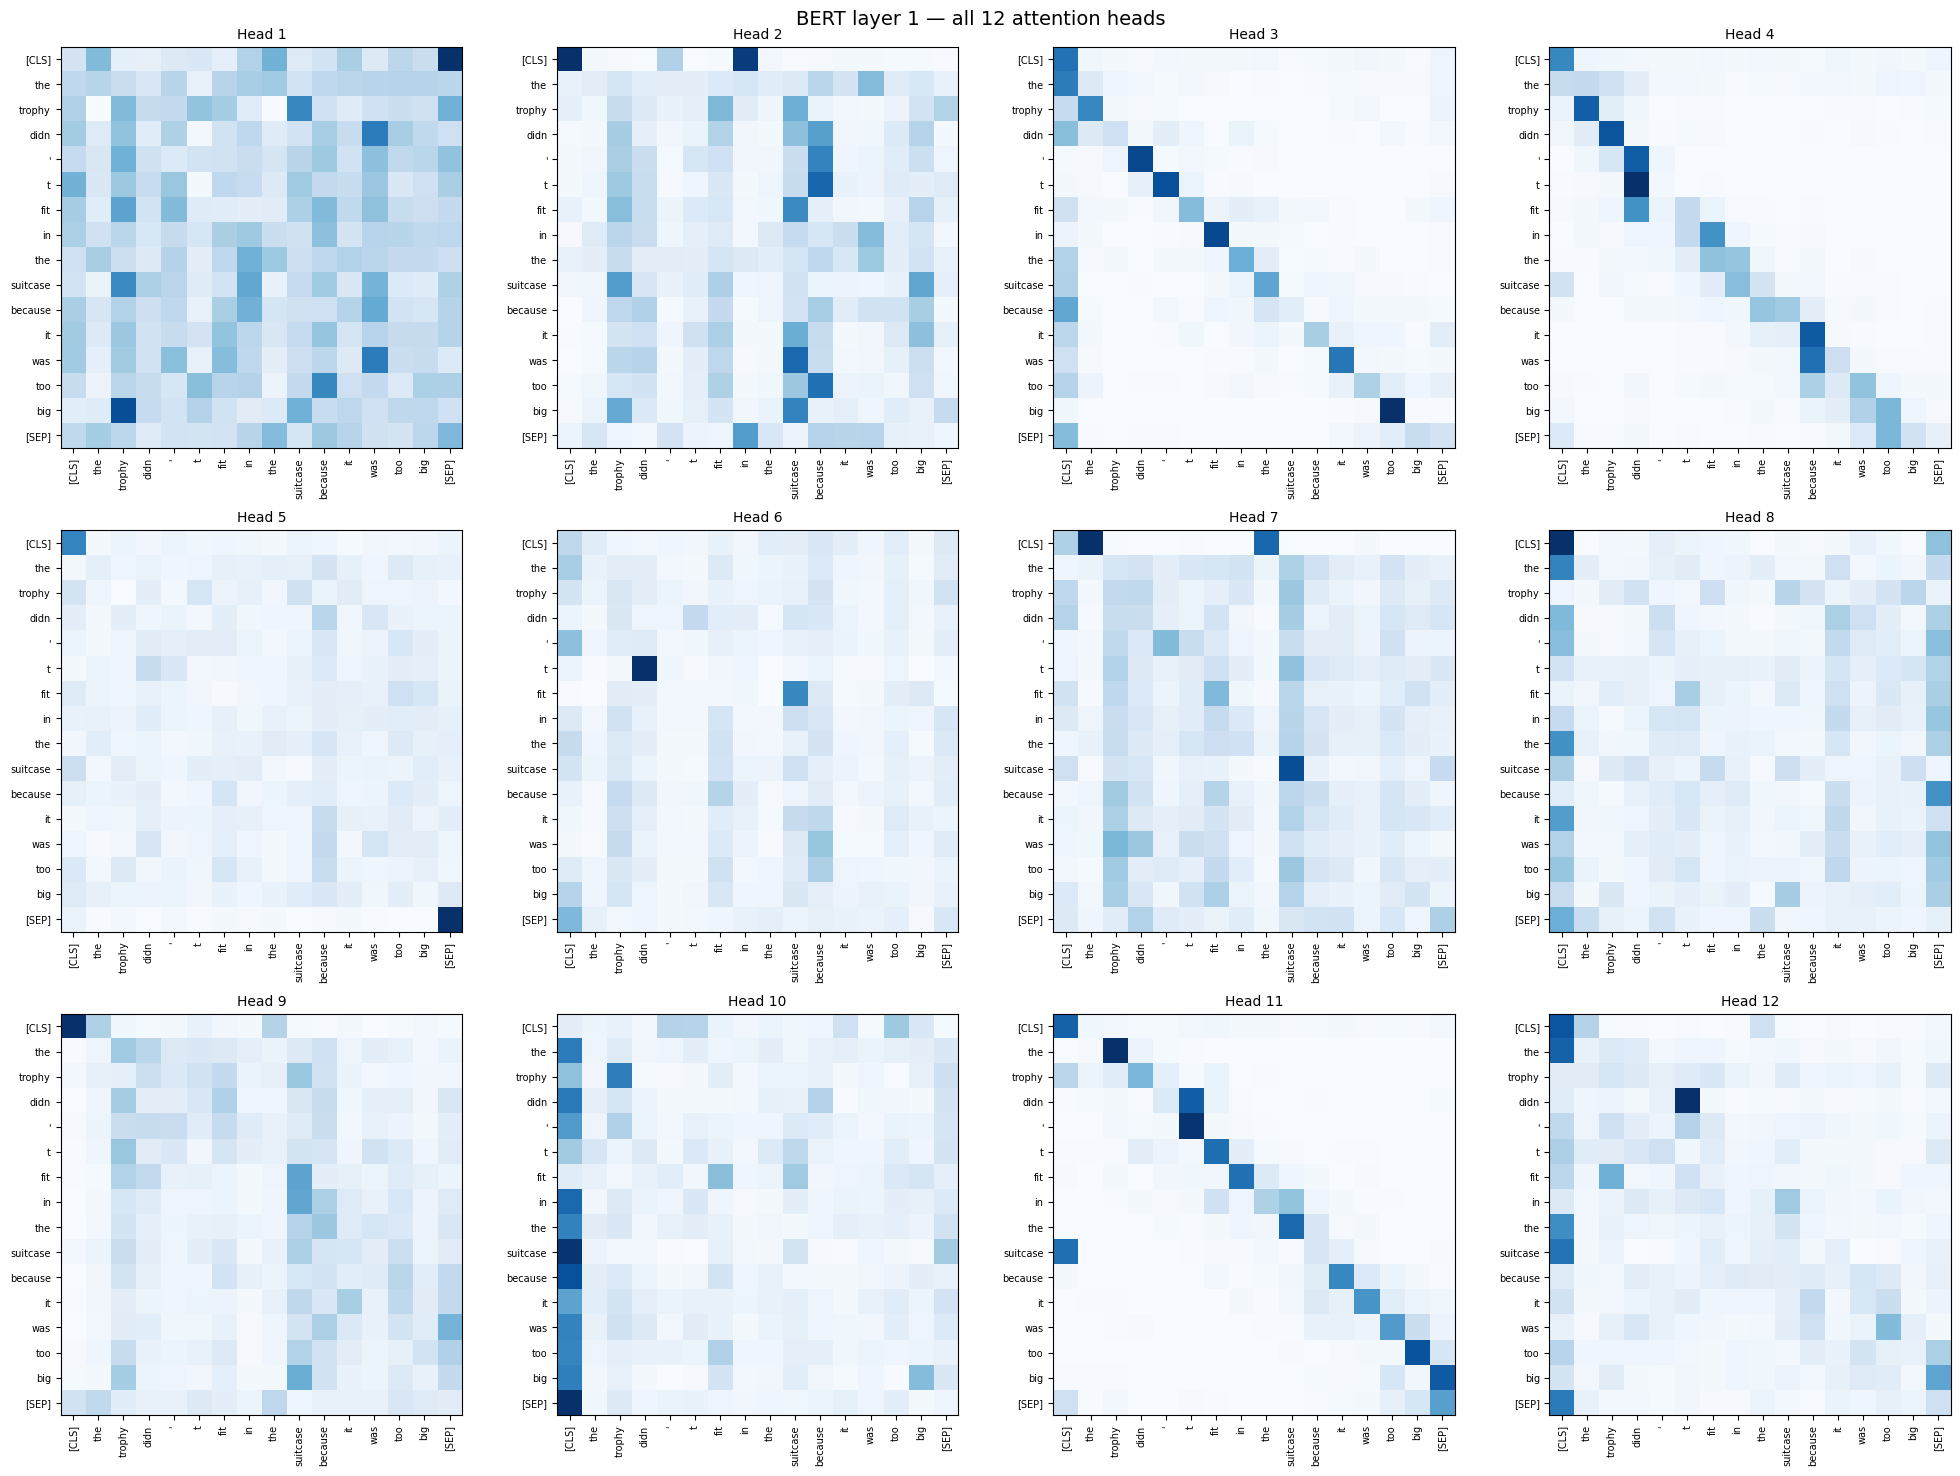

In [23]:
!pip install torch transformers -q

import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import numpy as np

# Load
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model.eval()  # inference mode, no dropout

# Tokenise
sentence = "The trophy didn't fit in the suitcase because it was too big"
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Forward pass — no_grad means don't track gradients, saves memory
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
# attentions = tuple of 12 layers
# each tensor shape: (batch=1, heads=12, seq_len, seq_len)

# Plot all 12 heads from layer 0
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

layer = 0
for head in range(12):
    attn = attentions[layer][0][head].numpy()
    ax = axes[head]
    im = ax.imshow(attn, cmap='Blues')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Head {head+1}', fontsize=10)

plt.suptitle('BERT layer 1 — all 12 attention heads', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
def self_attention(vec_emb,Wq,Wk,Wv,mask=None):
  Q=np.matmul(vec_emb,Wq)
  K=np.matmul(vec_emb,Wk)
  dk=K.shape[1]
  V=np.matmul(vec_emb,Wv)
  score=np.matmul(Q,np.transpose(K))
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  if mask is not None:
    score=score-mask

  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)

  output=np.matmul(weights,V)
  return output

In [26]:
def causal_mask(seq_len):
    mask = np.triu(np.ones((seq_len, seq_len)), k=1)
    return mask * 1e9

def self_attention(vec_emb,Wq,Wk,Wv,mask=None):
  Q=vec_emb@Wq
  K=vec_emb@Wk
  dk=K.shape[1]
  V=vec_emb@Wv
  score=Q@K.T
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  if mask is not None:
    score=score-mask

  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)

  output=np.matmul(weights,V)
  return output
print(causal_mask(5))

[[0.e+00 1.e+09 1.e+09 1.e+09 1.e+09]
 [0.e+00 0.e+00 1.e+09 1.e+09 1.e+09]
 [0.e+00 0.e+00 0.e+00 1.e+09 1.e+09]
 [0.e+00 0.e+00 0.e+00 0.e+00 1.e+09]
 [0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]]


In [49]:
def attention(Q_input,K_input,V_input,Wq,Wk,Wv,mask=None):
  Q=Q_input@Wq
  K=K_input@Wk
  dk=K.shape[1]
  V=V_input@Wv
  score=Q@K.T
  score=score/np.sqrt(dk)
  score=score-np.max(score,axis=1,keepdims=True)
  if mask is not None:
    score=score-mask

  exp1=np.exp(score)
  weights=exp1/np.sum(exp1,axis=1,keepdims=True)
  return weights@V

def multihead_attention(Q_input, K_input, V_input, n_head, mask=None):
    d_model = Q_input.shape[1]
    d_k = d_model // n_head
    output = []
    for i in range(n_head):
        Wq, Wk, Wv = calculate_WQ_WK_WV(d_model, d_k)
        op = attention(Q_input, K_input, V_input, Wq, Wk, Wv, mask=mask)
        output.append(op)
    return np.matmul(np.hstack(output), calculate_Wo(d_model))

def decoder(op_emb,encoder_output,n_heads,d_ff):
  d_k=op_emb.shape[1]//n_heads
  Wq=np.random.randn(op_emb.shape[1],d_k)
  Wk=np.random.randn(op_emb.shape[1],d_k)
  Wv=np.random.randn(op_emb.shape[1],d_k)

  att=multihead_attention(op_emb,op_emb,op_emb,n_heads,mask=causal_mask(op_emb.shape[0]))
  norm=layer_norm(op_emb+att,alpha=1,beta=0,eps=1e-6)
  Wqc=np.random.randn(op_emb.shape[1],d_k)
  Wkc=np.random.randn(op_emb.shape[1],d_k)
  Wvc=np.random.randn(op_emb.shape[1],d_k)

  cross_att=multihead_attention(norm,encoder_output,encoder_output,n_heads)
  norm2=layer_norm(norm+cross_att,alpha=1,beta=0,eps=1e-6)
  W1=np.random.randn(d_ff,op_emb.shape[1])
  b1=np.random.randn(d_ff,)
  W2=np.random.randn(op_emb.shape[1],d_ff)
  b2=np.random.rand(op_emb.shape[1],)
  norm3=layer_norm(norm2+ffn(norm2,op_emb.shape[1]),alpha=1,beta=0,eps=1e-6)
  return norm3






In [50]:
decoder_state = np.random.randn(3, 128)
encoder_output = np.random.randn(5, 128)
Wq = np.random.randn(128, 64)
Wk, Wv = np.random.randn(128, 64), np.random.randn(128, 64)
op=attention(decoder_state, encoder_output, encoder_output, Wq, Wk, Wv)
print(op.shape)

x = np.random.randn(3, 128)
enc_out = np.random.randn(5, 128)
out = decoder(x, enc_out, n_heads=8, d_ff=512)
print(out.shape)

(3, 64)
(3, 128)
